# 4팀 기계학습 프로젝트: US Accidents 교통사고 심각도 다중분류


## 전체 흐름
1. 라이브러리 불러오기 및 기본 설정
2. 데이터 경로 설정 및 CSV 로드
3. 전처리 및 파생변수 생성
4. Severity 기준 층화 샘플링
5. EDA 시각화
6. Train / Validation / Test 분할
7. 공통 전처리 파이프라인 구성
8. 모델 학습 및 Validation 비교
9. Test 평가 및 혼동행렬
10. 과적합/언더피팅 및 하이퍼파라미터 분석
11. 변수 중요도 분석
12. 선택 가산점: MLP 딥러닝 모델
13. 보고서 작성용 요약문 출력


## 1. 라이브러리 불러오기 및 기본 설정

이 단계에서는 데이터 처리, 시각화, 머신러닝 모델 학습에 필요한 라이브러리를 불러옵니다.  
`RANDOM_STATE`는 데이터를 나누거나 샘플링할 때 결과가 매번 달라지지 않도록 고정하는 값입니다.


In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.unicode_minus'] = False


## 2. 데이터 경로 설정

US Accidents CSV 파일 위치를 지정합니다.  
아래 코드는 자주 사용하는 경로 후보를 자동으로 확인합니다.

- 로컬 실행: `./data/US_Accidents_March23.csv`
- Colab + Google Drive: `/content/drive/MyDrive/기계학습프로젝트/US_Accidents_March23.csv`
- Colab 직접 업로드: `/content/US_Accidents_March23.csv`

파일을 다른 위치에 저장했다면 `CANDIDATE_PATHS`에 본인 경로를 추가하거나 `DATA_PATH`를 직접 지정하면 됩니다.


In [3]:
CANDIDATE_PATHS = [
    './data/US_Accidents_March23.csv',
    '/content/drive/MyDrive/기계학습프로젝트/US_Accidents_March23.csv',
    'C:/Users/USER/Desktop/기계학습 프로젝트/US_Accidents_March23.csv'
]

DATA_PATH = None
for path in CANDIDATE_PATHS:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        'US_Accidents_March23.csv 파일을 찾을 수 없습니다. '
        'DATA_PATH를 본인 파일 위치로 직접 수정하세요.'
    )

print('사용 데이터 경로:', DATA_PATH)


사용 데이터 경로: C:/Users/USER/Desktop/기계학습 프로젝트/US_Accidents_March23.csv


## 3. 필요한 컬럼만 로드

원본 데이터는 컬럼 수와 행 수가 매우 많습니다.  
프로젝트 요구사항에 맞춰 시간, 위치, 기상, 도로환경 관련 컬럼만 선택해서 불러옵니다.

이렇게 하면 메모리 사용량이 줄고 Colab에서도 실행하기 쉬워집니다.


In [5]:
USE_COLS = [
    'ID', 'Severity', 'Start_Time', 'End_Time',
    'Start_Lat', 'Start_Lng', 'Distance(mi)',
    'State', 'County', 'City', 'Timezone',
    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)',
    'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight',
    'Nautical_Twilight', 'Astronomical_Twilight',
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop'
]

header = pd.read_csv(DATA_PATH, nrows=0)
available_cols = [c for c in USE_COLS if c in header.columns]
missing_cols = [c for c in USE_COLS if c not in header.columns]

print('사용 가능 컬럼 수:', len(available_cols))
print('없는 컬럼:', missing_cols)

df = pd.read_csv(DATA_PATH, usecols=available_cols)

print('원본 로드 shape:', df.shape)
print('Severity 분포')
print(df['Severity'].value_counts().sort_index())
print('결측치 상위 20개')
print(df.isna().mean().sort_values(ascending=False).head(20))


사용 가능 컬럼 수: 37
없는 컬럼: []
원본 로드 shape: (7728394, 37)
Severity 분포
Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64
결측치 상위 20개
Precipitation(in)        0.285129
Wind_Chill(F)            0.258659
Wind_Speed(mph)          0.073914
Visibility(mi)           0.022915
Wind_Direction           0.022670
Humidity(%)              0.022533
Weather_Condition        0.022444
Temperature(F)           0.021201
Pressure(in)             0.018203
Nautical_Twilight        0.003008
Civil_Twilight           0.003008
Sunrise_Sunset           0.003008
Astronomical_Twilight    0.003008
Timezone                 0.001010
City                     0.000033
Railway                  0.000000
Start_Time               0.000000
End_Time                 0.000000
Start_Lat                0.000000
Turning_Loop             0.000000
dtype: float64


## 4. 전처리 함수 정의

이 함수는 원본 데이터를 모델 학습에 사용할 수 있는 형태로 바꿉니다.

주요 처리 내용은 다음과 같습니다.

- `Severity`가 1~4인 데이터만 사용
- `Start_Time`, `End_Time`을 날짜/시간 자료형으로 변환
- 사고 지속시간 `Duration_Min` 생성
- 월, 요일, 시간, 주말 여부 생성
- 계절 `Season` 생성
- 시간대 `Time_Period` 생성
- 범주가 너무 많은 변수는 상위 30개만 유지하고 나머지는 `Other`로 묶음
- 식별자 또는 원본 시간 컬럼 제거


In [6]:
def preprocess_raw_data(raw_df: pd.DataFrame) -> pd.DataFrame:
    data = raw_df.copy()

    # Severity 1~4만 사용한다. 다중분류의 타깃 변수이다.
    data = data[data['Severity'].isin([1, 2, 3, 4])].copy()

    # 시간 컬럼을 datetime 형식으로 변환한다.
    data['Start_Time'] = pd.to_datetime(data['Start_Time'], errors='coerce')

    # 사고 지속시간을 분 단위로 계산한다.
    if 'End_Time' in data.columns:
        data['End_Time'] = pd.to_datetime(data['End_Time'], errors='coerce')
        data['Duration_Min'] = (data['End_Time'] - data['Start_Time']).dt.total_seconds() / 60

        # 음수 또는 24시간 초과 지속시간은 이상치로 보고 결측 처리한다.
        data.loc[(data['Duration_Min'] < 0) | (data['Duration_Min'] > 24 * 60), 'Duration_Min'] = np.nan
    else:
        data['Duration_Min'] = np.nan

    # 시간 관련 파생변수 생성
    data['Year'] = data['Start_Time'].dt.year
    data['Month'] = data['Start_Time'].dt.month
    data['DayOfWeek'] = data['Start_Time'].dt.dayofweek  # 0=월요일, 6=일요일
    data['Hour'] = data['Start_Time'].dt.hour
    data['Is_Weekend'] = data['DayOfWeek'].isin([5, 6]).astype(int)

    # 월 정보를 계절 정보로 변환
    def month_to_season(m):
        if pd.isna(m):
            return np.nan
        if m in [12, 1, 2]:
            return 'Winter'
        if m in [3, 4, 5]:
            return 'Spring'
        if m in [6, 7, 8]:
            return 'Summer'
        return 'Fall'

    data['Season'] = data['Month'].apply(month_to_season)

    # 시간대를 교통 분석에 해석하기 쉬운 구간으로 변환
    def hour_to_period(h):
        if pd.isna(h):
            return np.nan
        if 6 <= h <= 9:
            return 'Morning_Peak'
        if 10 <= h <= 15:
            return 'Daytime'
        if 16 <= h <= 19:
            return 'Evening_Peak'
        return 'Night'

    data['Time_Period'] = data['Hour'].apply(hour_to_period)

    # 범주가 너무 많은 변수는 상위 30개만 유지한다.
    for col in ['City', 'County', 'Weather_Condition']:
        if col in data.columns:
            top_values = data[col].value_counts().head(30).index
            data[col] = data[col].where(data[col].isin(top_values), 'Other')

    # 모델에 직접 사용하지 않을 식별자 및 원본 시간 컬럼 제거
    drop_cols = [c for c in ['ID', 'Start_Time', 'End_Time'] if c in data.columns]
    data = data.drop(columns=drop_cols)

    return data


## 5. 전처리 실행

앞에서 만든 전처리 함수를 실제 데이터에 적용합니다.  
이 단계 결과가 이후 EDA, 데이터 분할, 모델 학습에 사용됩니다.


In [7]:
processed = preprocess_raw_data(df)

print('전처리 후 shape:', processed.shape)
print('전처리 후 컬럼 목록')
print(processed.columns.tolist())
print('전처리 후 Severity 분포')
print(processed['Severity'].value_counts().sort_index())


전처리 후 shape: (7728394, 42)
전처리 후 컬럼 목록
['Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'City', 'County', 'State', 'Timezone', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Duration_Min', 'Year', 'Month', 'DayOfWeek', 'Hour', 'Is_Weekend', 'Season', 'Time_Period']
전처리 후 Severity 분포
Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64


## 6. Severity 기준 층화 샘플링

US Accidents 원본 데이터는 매우 크기 때문에 전체를 그대로 학습하면 시간이 오래 걸릴 수 있습니다.  
따라서 `Severity` 비율을 최대한 유지하면서 샘플링합니다.

- `SAMPLE_SIZE = 100_000`: 기본 10만 건 사용
- 실행이 느리면 `50_000` 또는 `30_000`으로 줄이면 됩니다.
- 샘플링 후에도 요구사항인 1,000건 이상은 충분히 만족합니다.


In [8]:
SAMPLE_SIZE = 100_000  # 너무 느리면 30_000 또는 50_000으로 줄이세요.

if len(processed) > SAMPLE_SIZE:
    sampled = (
        processed.groupby('Severity', group_keys=False)
        .apply(lambda x: x.sample(
            n=max(1, int(SAMPLE_SIZE * len(x) / len(processed))),
            random_state=RANDOM_STATE
        ))
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
else:
    sampled = processed.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print('샘플링 후 shape:', sampled.shape)
print('샘플링 후 Severity 비율')
print(sampled['Severity'].value_counts(normalize=True).sort_index())


샘플링 후 shape: (99998, 42)
샘플링 후 Severity 비율
Severity
1    0.008710
2    0.796686
3    0.168123
4    0.026481
Name: proportion, dtype: float64


## 7. EDA 1: Severity 클래스 분포

첫 번째 그래프는 예측 대상인 `Severity`의 클래스 분포를 확인합니다.  
클래스 불균형이 있으면 Accuracy만으로 모델을 평가하기 어렵기 때문에 Macro F1, 클래스별 Precision/Recall도 함께 확인해야 합니다.


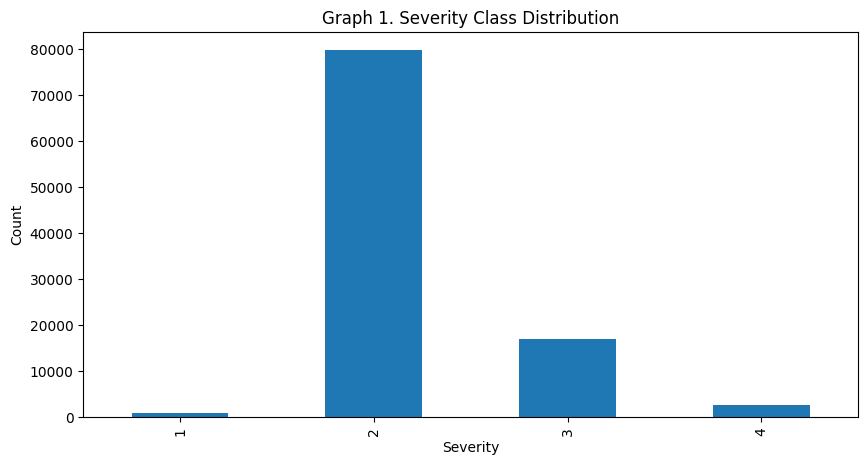

In [9]:
sampled['Severity'].value_counts().sort_index().plot(kind='bar')
plt.title('Graph 1. Severity Class Distribution')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.show()


## 8. EDA 2~4: 월별, 요일별, 시간대별 사고 분포

시간 관련 변수는 교통사고 발생 패턴을 이해하는 데 중요합니다.  
월별, 요일별, 시간대별 사고 수를 확인하여 특정 시기나 시간대에 사고가 집중되는지 살펴봅니다.


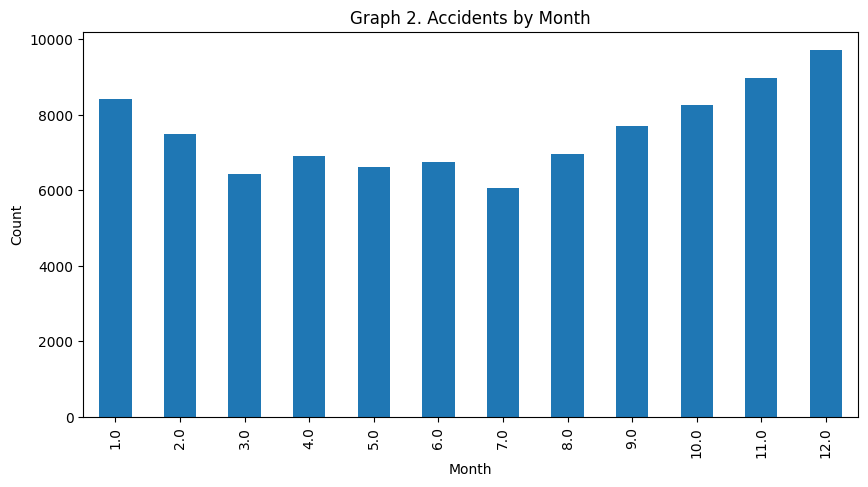

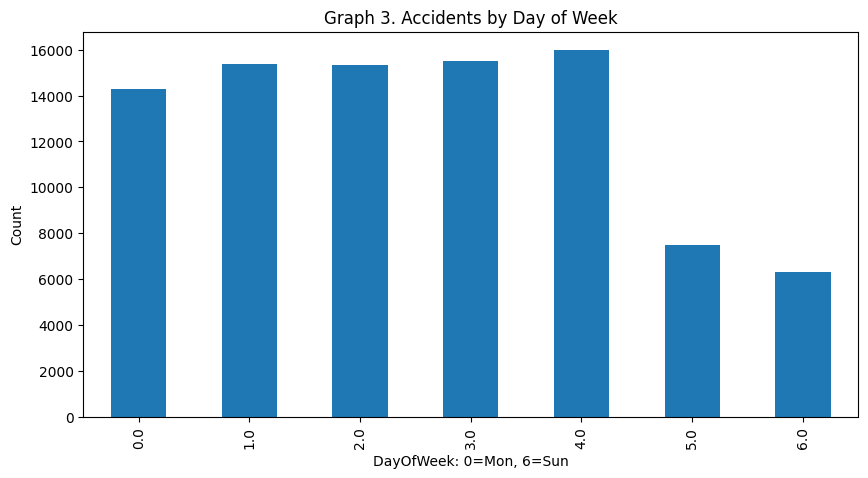

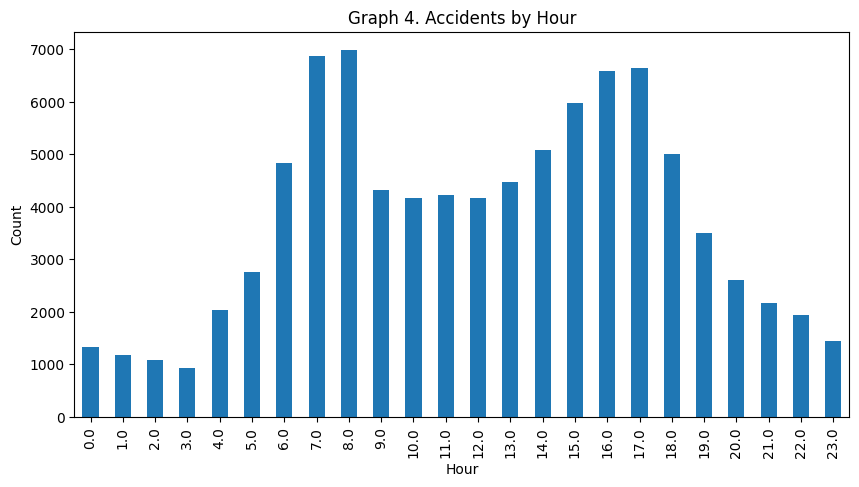

In [10]:
sampled['Month'].value_counts().sort_index().plot(kind='bar')
plt.title('Graph 2. Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

sampled['DayOfWeek'].value_counts().sort_index().plot(kind='bar')
plt.title('Graph 3. Accidents by Day of Week')
plt.xlabel('DayOfWeek: 0=Mon, 6=Sun')
plt.ylabel('Count')
plt.show()

sampled['Hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Graph 4. Accidents by Hour')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()


## 9. EDA 5~6: 기상 관련 변수 분포

교통사고 심각도는 기상 조건과 관련될 수 있습니다.  
온도 분포와 Severity별 시정거리 분포를 확인합니다.


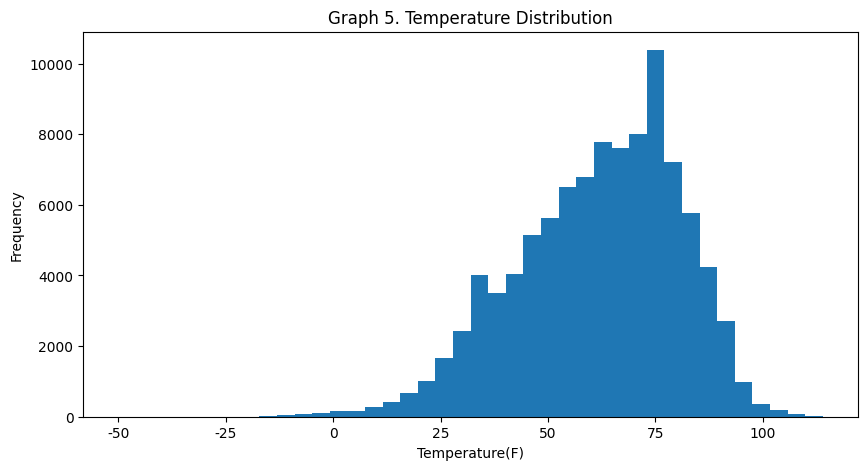

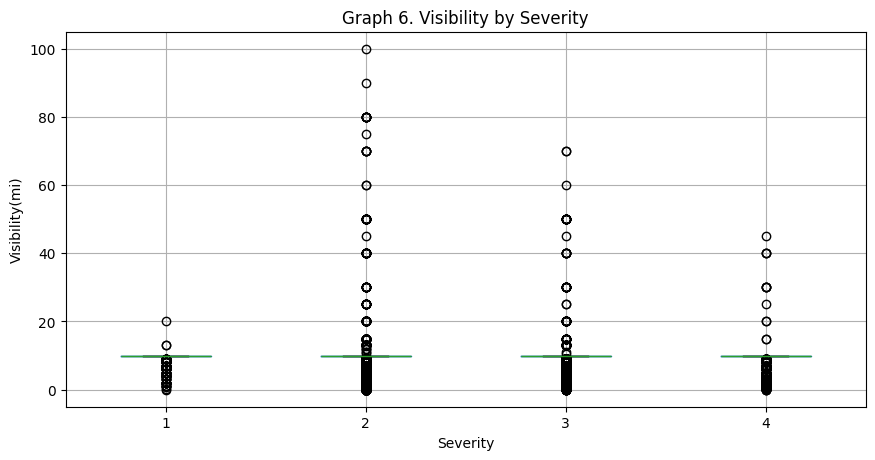

In [11]:
if 'Temperature(F)' in sampled.columns:
    sampled['Temperature(F)'].dropna().plot(kind='hist', bins=40)
    plt.title('Graph 5. Temperature Distribution')
    plt.xlabel('Temperature(F)')
    plt.ylabel('Frequency')
    plt.show()

if 'Visibility(mi)' in sampled.columns:
    sampled.boxplot(column='Visibility(mi)', by='Severity')
    plt.title('Graph 6. Visibility by Severity')
    plt.suptitle('')
    plt.xlabel('Severity')
    plt.ylabel('Visibility(mi)')
    plt.show()


## 10. EDA 7: 도로환경 변수 비율

교차로, 신호등, 정지 표지, 철도, 과속방지턱 등 도로환경 관련 변수의 출현 비율을 확인합니다.  
이 변수들은 사고가 발생한 주변 도로 조건을 나타냅니다.


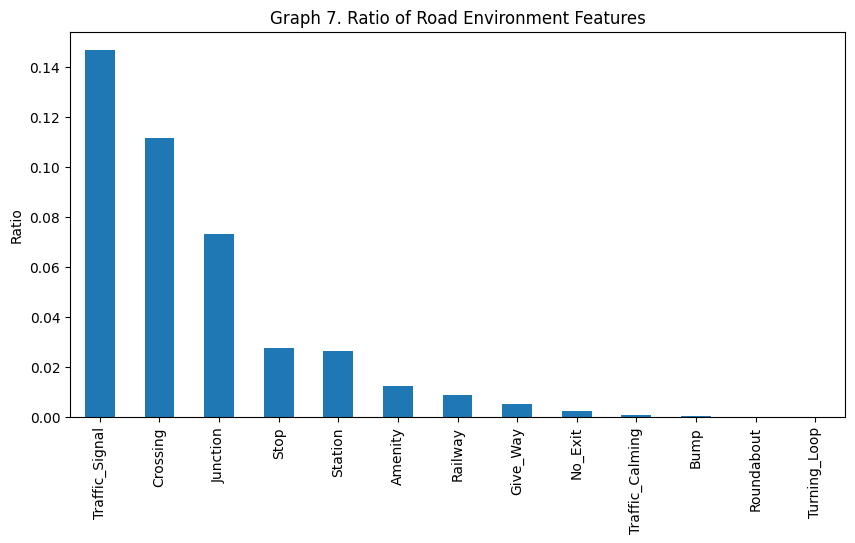

In [12]:
road_features = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop'
]
road_features = [c for c in road_features if c in sampled.columns]

if road_features:
    sampled[road_features].mean().sort_values(ascending=False).plot(kind='bar')
    plt.title('Graph 7. Ratio of Road Environment Features')
    plt.ylabel('Ratio')
    plt.show()


## 11. EDA 8~10: 지역 분포와 상관관계

지역별 사고 분포, 사고 위치 산점도, 수치형 변수 간 상관관계를 확인합니다.  
상관관계 그래프는 변수 간 중복성이나 선형적 관계를 확인하는 데 도움이 됩니다.


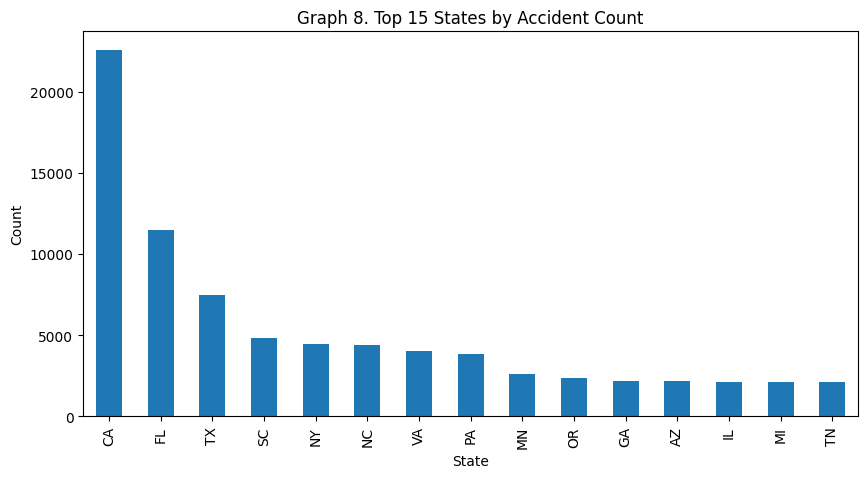

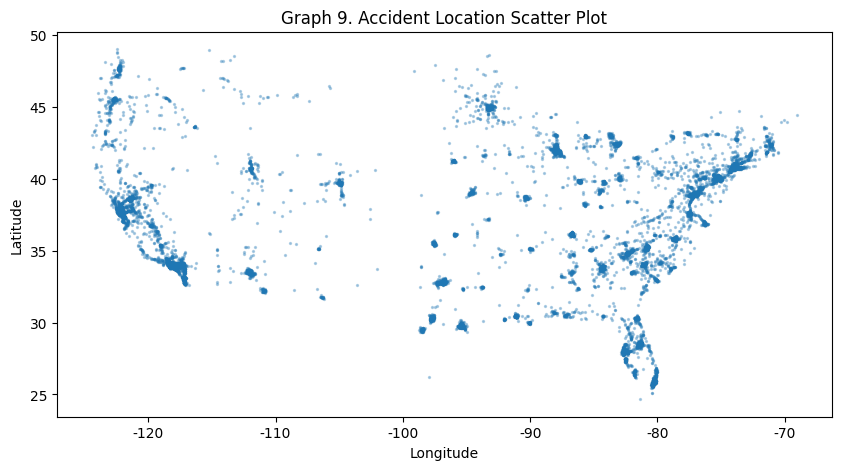

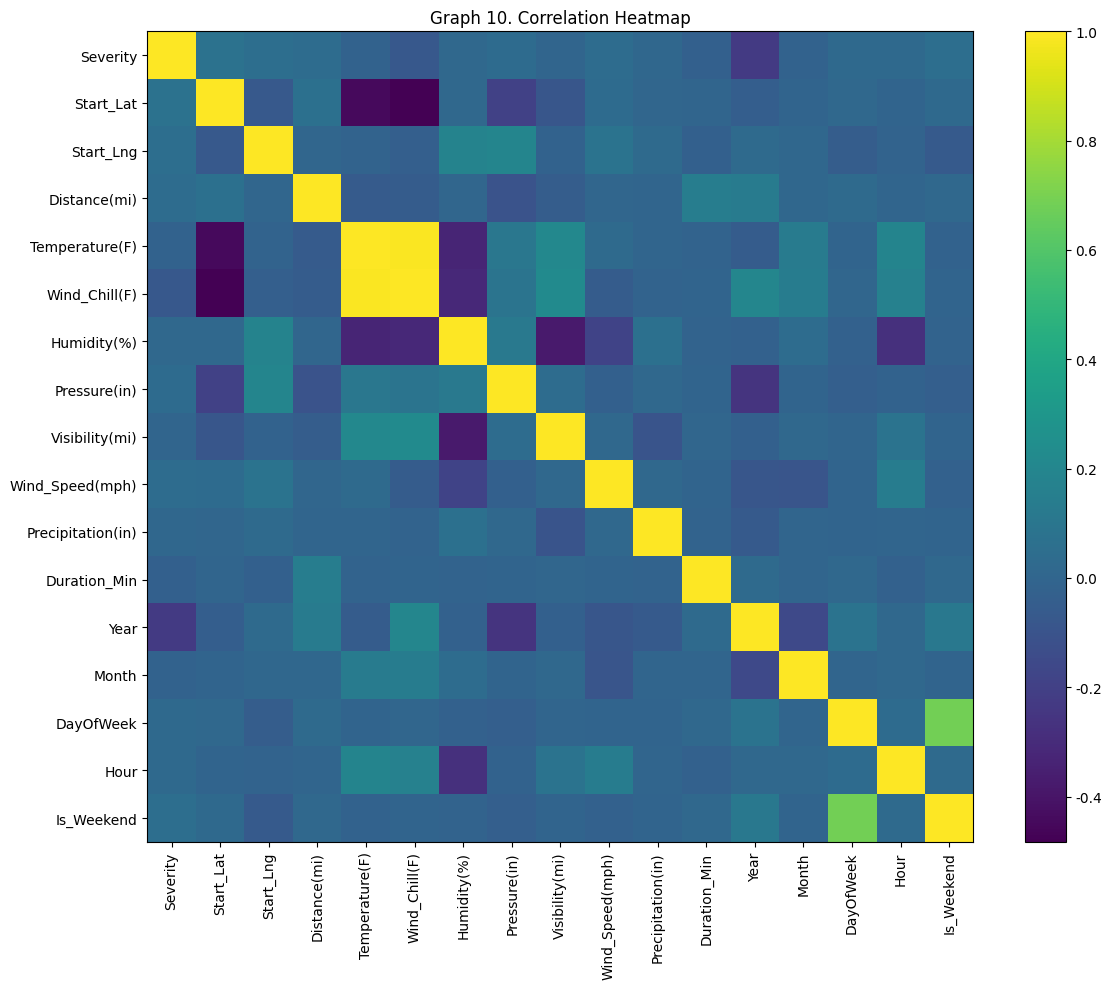

In [13]:
if 'State' in sampled.columns:
    sampled['State'].value_counts().head(15).plot(kind='bar')
    plt.title('Graph 8. Top 15 States by Accident Count')
    plt.xlabel('State')
    plt.ylabel('Count')
    plt.show()

if {'Start_Lng', 'Start_Lat'}.issubset(sampled.columns):
    geo_sample = sampled.sample(min(10000, len(sampled)), random_state=RANDOM_STATE)
    plt.scatter(geo_sample['Start_Lng'], geo_sample['Start_Lat'], s=2, alpha=0.3)
    plt.title('Graph 9. Accident Location Scatter Plot')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

numeric_cols_for_corr = sampled.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
if len(numeric_cols_for_corr) >= 2:
    corr = sampled[numeric_cols_for_corr].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr, aspect='auto')
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    plt.colorbar(im, ax=ax)
    plt.title('Graph 10. Correlation Heatmap')
    plt.tight_layout()
    plt.show()


## 12. 입력 변수 X와 타깃 변수 y 분리

`Severity`는 예측해야 하는 정답이므로 `y`로 분리합니다.  
나머지 변수들은 입력 피처 `X`로 사용합니다.

또한 수치형 변수와 범주형 변수를 나누어 이후 전처리 파이프라인에서 다르게 처리합니다.


In [14]:
X = sampled.drop(columns=['Severity'])
y = sampled['Severity'].astype(int)

numeric_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

print('수치형 피처 수:', len(numeric_features))
print('범주형 피처 수:', len(categorical_features))
print('전체 피처 수:', len(numeric_features) + len(categorical_features))
print('수치형 피처:', numeric_features)
print('범주형 피처:', categorical_features)


수치형 피처 수: 16
범주형 피처 수: 25
전체 피처 수: 41
수치형 피처: ['Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Duration_Min', 'Year', 'Month', 'DayOfWeek', 'Hour', 'Is_Weekend']
범주형 피처: ['City', 'County', 'State', 'Timezone', 'Wind_Direction', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Season', 'Time_Period']


## 13. Train / Validation / Test 분할

계획서와 프로젝트 요구사항에 맞게 모든 모델에 동일한 데이터 분할을 적용합니다.

- Train: 모델 학습용
- Validation: 모델 선택 및 하이퍼파라미터 비교용
- Test: 최종 성능 평가용

`stratify=y`를 사용하여 Severity 클래스 비율이 각 데이터셋에서 비슷하게 유지되도록 합니다.


In [15]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

print('Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

print('Train Severity 비율')
print(y_train.value_counts(normalize=True).sort_index())
print('Validation Severity 비율')
print(y_val.value_counts(normalize=True).sort_index())
print('Test Severity 비율')
print(y_test.value_counts(normalize=True).sort_index())


Train: (59998, 41)
Validation: (20000, 41)
Test: (20000, 41)
Train Severity 비율
Severity
1    0.008717
2    0.796677
3    0.168122
4    0.026484
Name: proportion, dtype: float64
Validation Severity 비율
Severity
1    0.00870
2    0.79670
3    0.16815
4    0.02645
Name: proportion, dtype: float64
Test Severity 비율
Severity
1    0.0087
2    0.7967
3    0.1681
4    0.0265
Name: proportion, dtype: float64


## 14. 공통 전처리 Pipeline 구성

모든 모델이 같은 전처리를 거치도록 `ColumnTransformer`와 `Pipeline`을 사용합니다.

수치형 변수:
- 결측치: 중앙값으로 대체
- 스케일링: 표준화 적용

범주형 변수:
- 결측치: 최빈값으로 대체
- 인코딩: One-Hot Encoding 적용

이 구조를 사용하면 데이터 누수를 줄이고, 모델별 비교가 공정해집니다.


In [16]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

try:
    categorical_encoder = OneHotEncoder(
        handle_unknown='ignore',
        min_frequency=20,
        sparse_output=False
    )
except TypeError:
    categorical_encoder = OneHotEncoder(
        handle_unknown='ignore',
        sparse=False
    )

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', categorical_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)


## 15. 평가 함수 정의

모델별 성능을 같은 기준으로 비교하기 위해 평가 함수를 만듭니다.

사용 지표는 다음과 같습니다.

- Accuracy: 전체 정답률
- Macro F1: 클래스별 F1을 단순 평균한 값으로, 클래스 불균형 상황에서 중요함
- Weighted F1: 클래스 비율을 반영한 F1
- Macro Precision
- Macro Recall


In [17]:
def evaluate_model(name, model, X_data, y_true):
    y_pred = model.predict(X_data)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro_F1': f1_score(y_true, y_pred, average='macro'),
        'Weighted_F1': f1_score(y_true, y_pred, average='weighted'),
        'Macro_Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro_Recall': recall_score(y_true, y_pred, average='macro', zero_division=0)
    }


def print_detail_report(name, model, X_data, y_true):
    y_pred = model.predict(X_data)
    print(f'[{name}] Classification Report')
    print(classification_report(y_true, y_pred, zero_division=0))


## 16. 모델 정의

계획서 기준에 맞춰 3개 모델을 비교합니다.

1. Logistic Regression: 기준 모델
2. Random Forest: 비선형 관계와 변수 중요도 해석에 유리
3. Gradient Boosting 계열: 여러 약한 모델을 순차적으로 결합하는 앙상블 모델

모든 모델은 앞에서 만든 동일한 `preprocessor`를 거칩니다.


In [18]:
models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=18,
            min_samples_leaf=3,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    'Gradient Boosting': Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.08,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE
        ))
    ])
}


## 17. 모델 학습 및 Validation 성능 비교

각 모델을 Train 데이터로 학습한 뒤 Validation 데이터에서 성능을 비교합니다.  
최종 모델은 Validation Macro F1이 가장 높은 모델로 선택합니다.


학습 중: Logistic Regression
학습 중: Random Forest
학습 중: Gradient Boosting
Validation 성능 비교
                 Model  Accuracy  Macro_F1  Weighted_F1  Macro_Precision  \
2    Gradient Boosting   0.85085  0.557307     0.836197         0.679229   
1        Random Forest   0.75060  0.524025     0.772416         0.478273   
0  Logistic Regression   0.53485  0.360150     0.609459         0.373532   

   Macro_Recall  
2      0.508470  
1      0.625697  
0      0.667542  


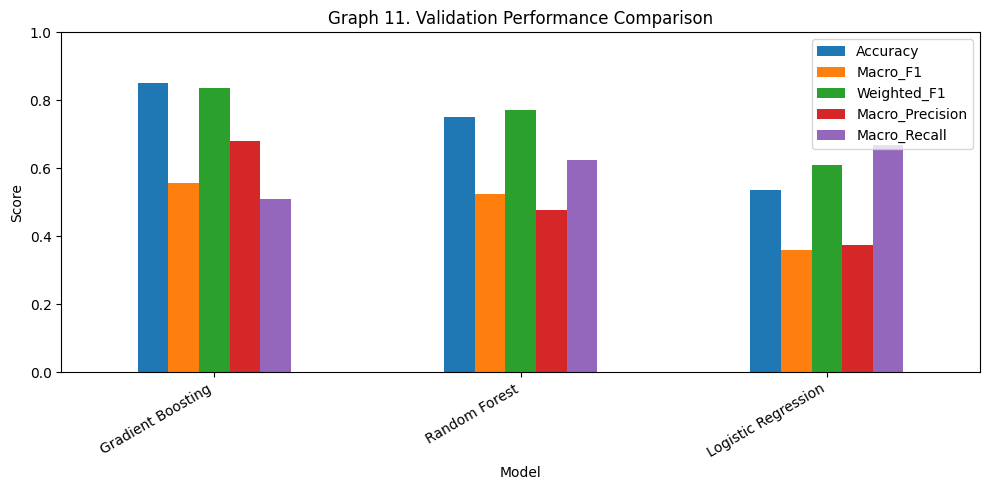

Validation 기준 최종 선택 모델: Gradient Boosting


In [19]:
val_results = []
trained_models = {}

for name, model in models.items():
    print(f'학습 중: {name}')
    model.fit(X_train, y_train)
    trained_models[name] = model
    val_results.append(evaluate_model(name, model, X_val, y_val))

val_result_df = pd.DataFrame(val_results).sort_values('Macro_F1', ascending=False)
print('Validation 성능 비교')
print(val_result_df)

metric_cols = ['Accuracy', 'Macro_F1', 'Weighted_F1', 'Macro_Precision', 'Macro_Recall']
val_result_df.set_index('Model')[metric_cols].plot(kind='bar')
plt.title('Graph 11. Validation Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

best_model_name = val_result_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print('Validation 기준 최종 선택 모델:', best_model_name)


## 18. Validation 상세 리포트 확인

단순 점수만 보면 어떤 클래스에서 성능이 낮은지 알기 어렵습니다.  
따라서 모델별 Classification Report를 출력하여 클래스별 Precision, Recall, F1-score를 확인합니다.


In [20]:
for name, model in trained_models.items():
    print('' + '=' * 80)
    print_detail_report(name, model, X_val, y_val)


[Logistic Regression] Classification Report
              precision    recall  f1-score   support

           1       0.08      0.87      0.14       174
           2       0.93      0.50      0.65     15934
           3       0.40      0.65      0.49      3363
           4       0.09      0.65      0.15       529

    accuracy                           0.53     20000
   macro avg       0.37      0.67      0.36     20000
weighted avg       0.81      0.53      0.61     20000

[Random Forest] Classification Report
              precision    recall  f1-score   support

           1       0.32      0.63      0.43       174
           2       0.92      0.77      0.84     15934
           3       0.45      0.75      0.56      3363
           4       0.22      0.36      0.27       529

    accuracy                           0.75     20000
   macro avg       0.48      0.63      0.52     20000
weighted avg       0.82      0.75      0.77     20000

[Gradient Boosting] Classification Report
      

## 19. Test 데이터 최종 평가

Validation에서 선택한 최종 모델을 포함하여 모든 모델을 Test 데이터에서 다시 평가합니다.  
Test 데이터는 모델 선택 과정에 사용하지 않았으므로 최종 일반화 성능을 확인하는 용도입니다.


In [21]:
test_results = []
for name, model in trained_models.items():
    test_results.append(evaluate_model(name, model, X_test, y_test))

test_result_df = pd.DataFrame(test_results).sort_values('Macro_F1', ascending=False)
print('Test 성능 비교')
print(test_result_df)

print('최종 선택 모델 Test 상세 리포트')
print_detail_report(best_model_name, best_model, X_test, y_test)


Test 성능 비교
                 Model  Accuracy  Macro_F1  Weighted_F1  Macro_Precision  \
2    Gradient Boosting    0.8460  0.536601     0.830811         0.641294   
1        Random Forest    0.7510  0.511810     0.772888         0.467992   
0  Logistic Regression    0.5354  0.355242     0.610752         0.369666   

   Macro_Recall  
2      0.494726  
1      0.611211  
0      0.641180  
최종 선택 모델 Test 상세 리포트
[Gradient Boosting] Classification Report
              precision    recall  f1-score   support

           1       0.57      0.42      0.48       174
           2       0.88      0.95      0.91     15934
           3       0.68      0.50      0.57      3362
           4       0.45      0.11      0.18       530

    accuracy                           0.85     20000
   macro avg       0.64      0.49      0.54     20000
weighted avg       0.83      0.85      0.83     20000



## 20. 최종 모델 혼동행렬

혼동행렬은 실제 클래스와 예측 클래스가 어떻게 다른지 보여줍니다.  
특히 Severity 1, 3, 4처럼 데이터가 적은 클래스가 다른 클래스로 많이 예측되는지 확인할 수 있습니다.


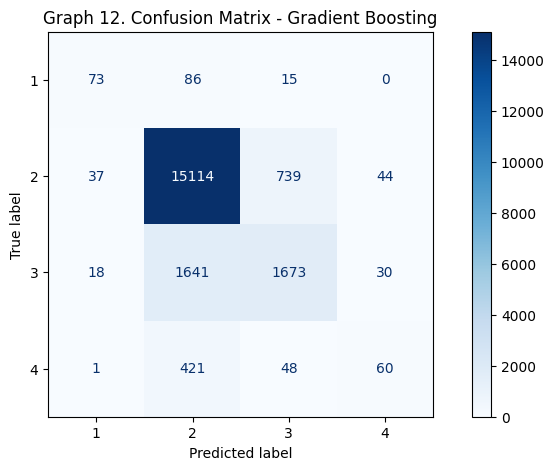

In [22]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title(f'Graph 12. Confusion Matrix - {best_model_name}')
plt.show()


## 21. 하이퍼파라미터 변경 효과 및 과적합 분석

Random Forest의 `max_depth`를 바꿔가며 Train Macro F1과 Validation Macro F1을 비교합니다.

해석 기준:
- Train 점수와 Validation 점수가 모두 낮으면 언더피팅 가능성
- Train 점수는 높고 Validation 점수가 낮으면 과적합 가능성
- 두 점수 차이가 작고 Validation 점수가 높으면 비교적 적절한 복잡도


Random Forest max_depth 변경 결과
  max_depth  Train_Macro_F1  Val_Macro_F1
0         6        0.314702      0.312319
1        10        0.419777      0.394945
2        14        0.546695      0.463847
3        18        0.710016      0.518081
4      None        0.897897      0.560939


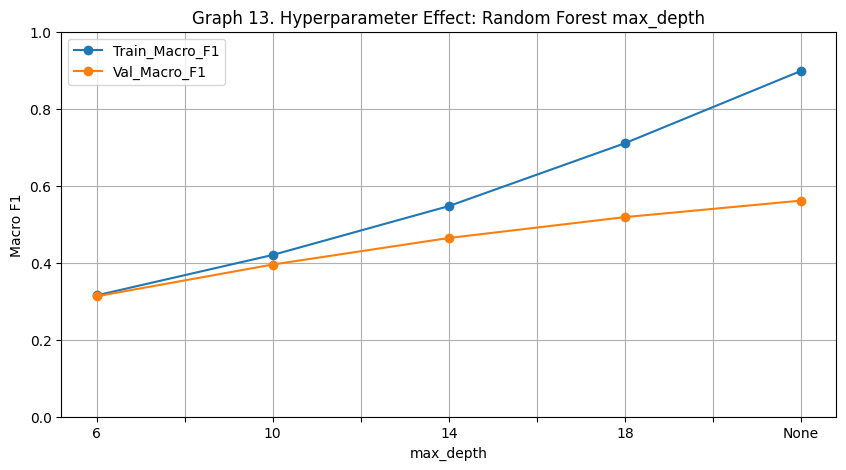

In [23]:
depth_list = [6, 10, 14, 18, None]
hp_results = []

for depth in depth_list:
    rf_model = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=120,
            max_depth=depth,
            min_samples_leaf=3,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    rf_model.fit(X_train, y_train)
    train_pred = rf_model.predict(X_train)
    val_pred = rf_model.predict(X_val)

    hp_results.append({
        'max_depth': str(depth),
        'Train_Macro_F1': f1_score(y_train, train_pred, average='macro'),
        'Val_Macro_F1': f1_score(y_val, val_pred, average='macro')
    })

hp_df = pd.DataFrame(hp_results)
print('Random Forest max_depth 변경 결과')
print(hp_df)

hp_df.set_index('max_depth')[['Train_Macro_F1', 'Val_Macro_F1']].plot(marker='o')
plt.title('Graph 13. Hyperparameter Effect: Random Forest max_depth')
plt.xlabel('max_depth')
plt.ylabel('Macro F1')
plt.ylim(0, 1)
plt.grid(True)
plt.show()


## 22. Random Forest 변수 중요도

Random Forest는 모델 내부의 `feature_importances_`를 통해 어떤 변수가 예측에 많이 사용되었는지 확인할 수 있습니다.  
범주형 변수는 One-Hot Encoding 이후 여러 개의 더미 변수로 나뉘어 표시됩니다.


Random Forest 변수 중요도 Top 20
                    feature  importance
2              Distance(mi)    0.147285
10             Duration_Min    0.101113
11                     Year    0.096467
4             Wind_Chill(F)    0.047955
1                 Start_Lng    0.038425
0                 Start_Lat    0.037462
6              Pressure(in)    0.034460
12                    Month    0.032597
3            Temperature(F)    0.029572
5               Humidity(%)    0.025454
14                     Hour    0.022957
8           Wind_Speed(mph)    0.019680
220           Season_Winter    0.018830
13                DayOfWeek    0.016353
206    Traffic_Signal_False    0.015833
207     Traffic_Signal_True    0.015009
70             County_Other    0.011902
218           Season_Spring    0.011406
219           Season_Summer    0.011330
156  Weather_Condition_Fair    0.010997


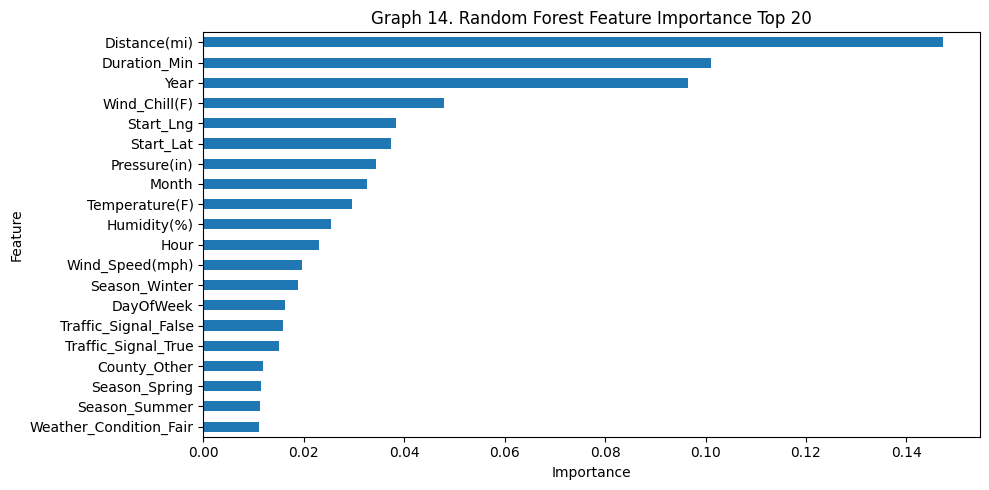

In [24]:
def get_feature_names_from_pipeline(pipeline):
    pre = pipeline.named_steps['preprocess']
    feature_names = []

    # 수치형 변수 이름
    feature_names.extend(numeric_features)

    # 범주형 변수의 One-Hot Encoding 이후 이름
    if len(categorical_features) > 0:
        cat_pipe = pre.named_transformers_['cat']
        ohe_model = cat_pipe.named_steps['onehot']
        feature_names.extend(ohe_model.get_feature_names_out(categorical_features).tolist())

    return feature_names

if 'Random Forest' in trained_models:
    rf = trained_models['Random Forest']
    rf_model = rf.named_steps['model']
    feature_names = get_feature_names_from_pipeline(rf)

    fi_df = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False).head(20)

    print('Random Forest 변수 중요도 Top 20')
    print(fi_df)

    fi_df.sort_values('importance').plot(kind='barh', x='feature', y='importance', legend=False)
    plt.title('Graph 14. Random Forest Feature Importance Top 20')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


## 23. Permutation Importance

Permutation Importance는 특정 변수를 섞었을 때 모델 성능이 얼마나 떨어지는지 확인하는 방법입니다.  
모델 종류와 관계없이 사용할 수 있어 최종 선택 모델의 변수 영향도를 해석하는 데 유용합니다.

계산 시간이 오래 걸릴 수 있으므로 Test 데이터 중 일부만 사용합니다.


Permutation Importance Top 15
           feature  importance_mean  importance_std
34            Year         0.159578        0.009580
2     Distance(mi)         0.113864        0.024243
33    Duration_Min         0.105906        0.017324
0        Start_Lat         0.054321        0.010938
1        Start_Lng         0.047691        0.007425
35           Month         0.044258        0.021584
4           County         0.037181        0.015160
40     Time_Period         0.036660        0.019605
39          Season         0.034653        0.014944
27  Traffic_Signal         0.025580        0.015442
5            State         0.024670        0.004284
18        Crossing         0.009746        0.003294
3             City         0.007794        0.002909
36       DayOfWeek         0.007094        0.006501
10    Pressure(in)         0.002404        0.015245


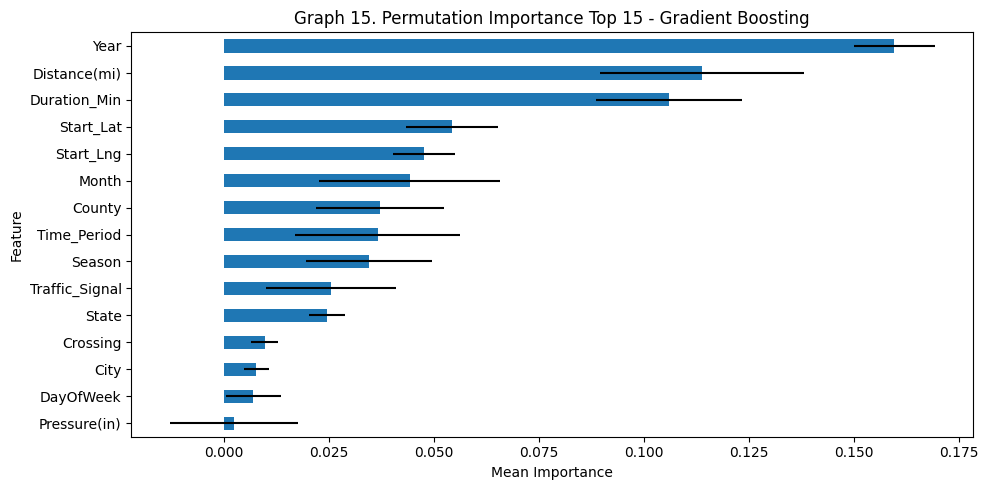

In [25]:
perm_sample_size = min(3000, len(X_test))
X_perm = X_test.sample(perm_sample_size, random_state=RANDOM_STATE)
y_perm = y_test.loc[X_perm.index]

perm = permutation_importance(
    best_model,
    X_perm,
    y_perm,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='f1_macro',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_perm.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False).head(15)

print('Permutation Importance Top 15')
print(perm_df)

perm_df.sort_values('importance_mean').plot(
    kind='barh',
    x='feature',
    y='importance_mean',
    xerr='importance_std',
    legend=False
)
plt.title(f'Graph 15. Permutation Importance Top 15 - {best_model_name}')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 24. 선택 가산점: TensorFlow Keras MLP

프로젝트 요구사항에서 딥러닝 모델은 선택 가산점 항목입니다.  
기본값은 `RUN_MLP = False`로 두었습니다.

Colab에서 TensorFlow가 설치되어 있고 시간이 충분하면 `RUN_MLP = True`로 바꿔 실행하면 됩니다.


Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7936 - loss: 0.5746 - val_accuracy: 0.8066 - val_loss: 0.4904
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8090 - loss: 0.5011 - val_accuracy: 0.8130 - val_loss: 0.4720
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8118 - loss: 0.4810 - val_accuracy: 0.8176 - val_loss: 0.4603
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8165 - loss: 0.4671 - val_accuracy: 0.8173 - val_loss: 0.4552
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8189 - loss: 0.4585 - val_accuracy: 0.8201 - val_loss: 0.4467
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8213 - loss: 0.4495 - val_accuracy: 0.8212 - val_loss: 0.4411
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8239 - loss: 0.4403 - val_accuracy: 0.8233 - val_loss: 0.4353
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8261 - loss: 0.4325 - val_accuracy: 

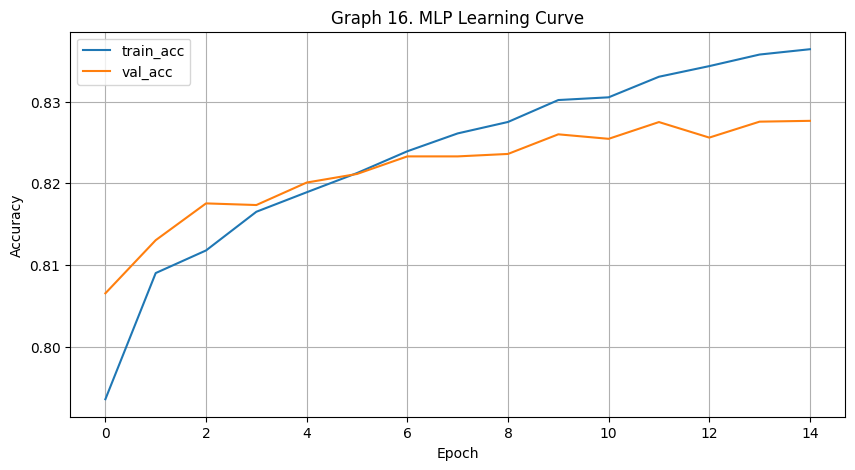

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           1       0.56      0.18      0.28       174
           2       0.85      0.95      0.90     15934
           3       0.61      0.40      0.48      3362
           4       0.34      0.07      0.12       530

    accuracy                           0.82     20000
   macro avg       0.59      0.40      0.44     20000
weighted avg       0.80      0.82      0.80     20000

MLP Macro F1: 0.44260499450537194


In [26]:
RUN_MLP = True  # 실행하려면 True로 변경

if RUN_MLP:
    import tensorflow as tf
    from tensorflow.keras import layers, models

    # 기존 전처리기를 사용해 신경망 입력 형태로 변환한다.
    X_train_nn = preprocessor.fit_transform(X_train)
    X_val_nn = preprocessor.transform(X_val)
    X_test_nn = preprocessor.transform(X_test)

    # Severity 1~4를 0~3으로 변환한다.
    y_train_nn = y_train.values - 1
    y_val_nn = y_val.values - 1
    y_test_nn = y_test.values - 1

    mlp = models.Sequential([
        layers.Input(shape=(X_train_nn.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(4, activation='softmax')
    ])

    mlp.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = mlp.fit(
        X_train_nn,
        y_train_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=15,
        batch_size=256,
        verbose=1
    )

    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title('Graph 16. MLP Learning Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    y_pred_nn = np.argmax(mlp.predict(X_test_nn), axis=1) + 1
    print(classification_report(y_test, y_pred_nn, zero_division=0))
    print('MLP Macro F1:', f1_score(y_test, y_pred_nn, average='macro'))


## 25. 보고서 작성용 요약 출력

마지막으로 보고서에 바로 활용할 수 있도록 사용 샘플 수, 피처 수, 최종 선택 모델, Validation/Test 결과, 요약 문장을 출력합니다.  
실제 보고서에는 여기 출력된 값을 바탕으로 결과 해석을 작성하면 됩니다.


In [27]:
print('보고서 작성용 요약')
print('-' * 80)
print(f'사용 샘플 수: {len(sampled):,}건')
print(f'입력 피처 수: {len(numeric_features) + len(categorical_features)}개')
print(f'최종 선택 모델: {best_model_name}')

print('Validation 성능')
print(val_result_df)

print('Test 성능')
print(test_result_df)

best_test = test_result_df[test_result_df['Model'] == best_model_name].iloc[0]

report_sentence = ('본 프로젝트는 US Accidents(2016-2023) 데이터를 활용하여 사고 발생 시간, 위치, 기상, 도로환경 변수를 기반으로 '
    'Severity 1~4를 예측하는 다중분류 문제를 수행하였다.'
    '전처리 과정에서는 결측치 처리, 범주형 변수 인코딩, 시간 변수 파생, 고카디널리티 변수 축소를 수행하였고, '
    '모든 모델에 동일한 train/validation/test 분할을 적용하였다.'
    f'Validation Macro F1 기준 최종 선택 모델은 {best_model_name}이며, '
    f'Test set에서 Accuracy={best_test["Accuracy"]:.4f}, Macro F1={best_test["Macro_F1"]:.4f}, '
    f'Weighted F1={best_test["Weighted_F1"]:.4f}를 기록하였다.'
    '클래스별 Precision/Recall과 혼동행렬을 함께 확인한 결과, 전체 정확도뿐 아니라 클래스 불균형 상황에서의 '
    '소수 클래스 예측 성능을 함께 고려해야 함을 확인하였다.'
)

print(report_sentence)

보고서 작성용 요약
--------------------------------------------------------------------------------
사용 샘플 수: 99,998건
입력 피처 수: 41개
최종 선택 모델: Gradient Boosting
Validation 성능
                 Model  Accuracy  Macro_F1  Weighted_F1  Macro_Precision  \
2    Gradient Boosting   0.85085  0.557307     0.836197         0.679229   
1        Random Forest   0.75060  0.524025     0.772416         0.478273   
0  Logistic Regression   0.53485  0.360150     0.609459         0.373532   

   Macro_Recall  
2      0.508470  
1      0.625697  
0      0.667542  
Test 성능
                 Model  Accuracy  Macro_F1  Weighted_F1  Macro_Precision  \
2    Gradient Boosting    0.8460  0.536601     0.830811         0.641294   
1        Random Forest    0.7510  0.511810     0.772888         0.467992   
0  Logistic Regression    0.5354  0.355242     0.610752         0.369666   

   Macro_Recall  
2      0.494726  
1      0.611211  
0      0.641180  
본 프로젝트는 US Accidents(2016-2023) 데이터를 활용하여 사고 발생 시간, 위치, 기상, 도로환경 변수를 기반으로 